# InSilicoICH: Part 3. Running Studies

This notebook combines the pieces from [01_phantoms.ipynb](01_phantoms.ipynb) and [02_scanners.ipynb](02_scanners.ipynb) into the full pipeline, checkout those notebooks for more in depth coverage of each

This notebook introduces the `ICHStudy` class, which is an extension of the VITools Study class used to run studies with the phantoms and scanners defined in the previous notebooks. ICHStudy is a subclass of the VITools Study class, which provides additional functionality for adding intracranial hemorrhage (ICH) phantoms, metadata and measurements to the study. It also includes methods for running the study and generating reports.

In [1]:
from insilicoICH.study import ICHStudy, DistributionManager
from VITools import get_available_phantoms

In [2]:
lesion_volume = {'IPH': [1, 6], 'SDH': [1, 6], 'EDH': [1, 6]}
lesion_attn = {'IPH': [40, 90], 'SDH': [40, 90], 'EDH': [40, 90]}
vol_manager = DistributionManager(lesion_volume)
vol_manager

In [3]:
import numpy as np
rng = np.random.default_rng()

In [4]:
vol_manager.sample('IPH',  rng)

np.float64(3.2222222222222223)

In [5]:
available_phantoms = get_available_phantoms()
available_phantoms

{'LVO MIDA Head': functools.partial(<class 'InSilicoLVO.phantoms.LVO_MIDA'>, phantom_dir='/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/MIDA_Head_Phantom'),
 '0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial

In [6]:
ICHStudy?

Init signature: ICHStudy(input_csv: pandas.core.frame.DataFrame | str | None = None)
Docstring:      Manages the generation and execution of in silico ICH virtual trials.
Init docstring:
Initializes a Study instance.

Args:
    input_csv (pd.DataFrame | str | None, optional): 
        Path to a CSV file or a pandas DataFrame containing study metadata.
        If None, an empty study is initialized. Defaults to None.
File:           ~/Dev/PedSilicoICH/src/insilicoICH/study.py
Type:           type
Subclasses:     

In [7]:
ICHStudy.generate_from_distributions?

Signature:
ICHStudy.generate_from_distributions(
    phantoms: List[str],
    study_count: int = 1,
    subtype: List[Optional[str]] = [None, 'IPH', 'SDH', 'EDH'],
    lesion_volume: Union[Dict, str, pathlib.Path] = None,
    lesion_attenuation: Union[Dict, str, pathlib.Path] = None,
    edema_range: List[int] = [0, 15],
    mass_effect: list[bool | float] = [0.1, 0.9],
    texture_contrast: List[float] = [0, 50],
    texture_scale: List[float] = [8, 16],
    complexity: List[float] = [0, 4],
    smoothness: List[float] = [0.1, 0.4],
    irregularity: List[float] = [0.1, 0.4],
    eccentricity: List[float] = [0.4, 0.8],
    add_augmentation: bool = True,
    **kwargs,
) -> pandas.core.frame.DataFrame
Docstring: Generates a DataFrame of study parameters by sampling from distributions.
File:      ~/Dev/PedSilicoICH/src/insilicoICH/study.py
Type:      method

In [8]:
get_available_phantoms()

{'LVO MIDA Head': functools.partial(<class 'InSilicoLVO.phantoms.LVO_MIDA'>, phantom_dir='/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/MIDA_Head_Phantom'),
 '0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial

In [9]:
study_list = ICHStudy.generate_from_distributions(get_available_phantoms(),
                                                  lesion_volume=lesion_volume,
                                                  lesion_attenuation=lesion_attn,
                                                  study_count=5)
study_list

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,case_seed,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,add_augmentation
0,case_0000,0.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,781367,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,None,0.000000,0.000000,0,0.0,0.135977,True
1,case_0001,11.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,44970,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,EDH,3.171717,63.737374,0,11.5,0.177875,True
2,case_0002,10.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,430986,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,5.141414,80.404040,0,10.5,0.453356,True
3,case_0003,1.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,81716,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,None,0.000000,0.000000,0,1.0,0.187469,True
4,case_0004,10.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,475805,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,2.060606,59.191919,0,10.5,0.578310,True


In [10]:
study_list

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,case_seed,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,add_augmentation
0,case_0000,0.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,781367,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,None,0.000000,0.000000,0,0.0,0.135977,True
1,case_0001,11.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,44970,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,EDH,3.171717,63.737374,0,11.5,0.177875,True
2,case_0002,10.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,430986,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,5.141414,80.404040,0,10.5,0.453356,True
3,case_0003,1.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,81716,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,None,0.000000,0.000000,0,1.0,0.187469,True
4,case_0004,10.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,475805,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,2.060606,59.191919,0,10.5,0.578310,True


each lesion should be a class/object with control over its own frequency and characteristics and it knows how to insert itphantom into the phantom 

e.g. 

```python
sdh = ICHLesion(subtype='SDH', volume=5, attenuation=60)
phantom.insert(sdh)

fracture = Fracture(subtype='linear', thickness)
phantom.insert(fracture)
```

This is better than currently inserting lesions by a string argument and long list of attributes.

This could be an expansion of lesion_definition.Lesion which is currently only a data class

This would involve pulling _add_round_lesion and _add_dural_lesion out of LesionPhantom and into their own lesion objects. I still think the phantom should be responsible for how to handle mass effect because all it needs is the lesion mask then the phantom is aware of its own inclusion and exclusion masks.

In [11]:
from VITools import get_available_phantoms

phantom = get_available_phantoms()['9.0 yr NIHPD Head']()
# phantom.insert_lesion('SDH', volume=12, seed=206245, mass_effect=2.0)
phantom


        Phantom Class: NIHPD_Head
        Age (years): 9.0
        Shape (voxels): (189, 233, 197)
        Size (mm): (154.98, 191.06, 161.54)
        
Number of lesions: 0

In [12]:
from insilicoICH.lesion_definition import LesionFactory

# lesion = LesionFactory.create('SDH', dura_map=phantom.get_dura_map(), spacings=phantom.spacings, seed=12345)
lesion = LesionFactory.create('IPH', boundary_mask=phantom.get_material_mask('white matter'),
                              spacings=phantom.spacings, seed=1)
lesion.generate(volume_ml=12, intensity_hu=50, texture_contrast=1, texture_scale=12, complexity=3, smoothness=0.2,
                irregularity=0.5, eccentricity=0.6, edema=2)

Lesion(type=IPH, volume_ml=12.03, coords_voxel=(93, 86, 121), seed=1)

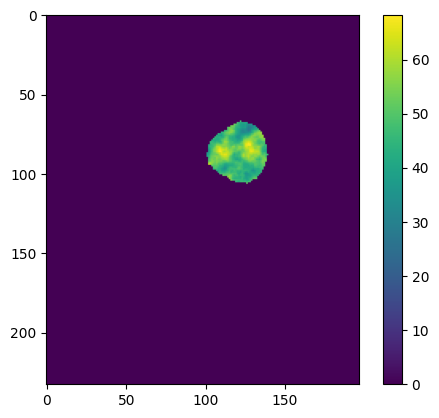

In [13]:
import matplotlib.pyplot as plt
plt.imshow(lesion.image[93])
plt.colorbar()

In [14]:
lesion = LesionFactory.create('IPH', boundary_mask=phantom.get_material_mask('white matter'),
                              spacings=phantom.spacings, seed=1)
lesion

Lesion(type=IPH, volume_ml=0.00, coords_voxel=None, seed=1)

In [15]:
lesion.generate(volume_ml=12, intensity_hu=50, texture_contrast=1, texture_scale=12, complexity=3, smoothness=0.2,
                irregularity=0.5, eccentricity=0.6, edema=2)

Lesion(type=IPH, volume_ml=12.03, coords_voxel=(93, 86, 121), seed=1)

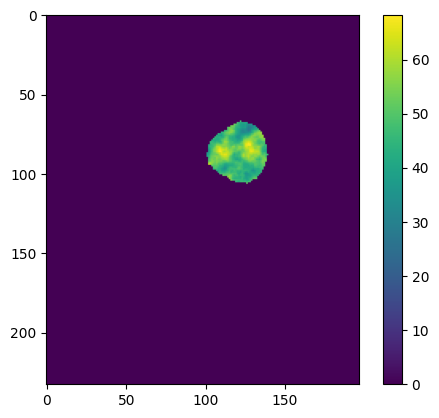

In [16]:
plt.imshow(lesion.image[lesion.coords_voxel[0]])
plt.colorbar()

In [17]:
phantom = get_available_phantoms()['9.0 yr NIHPD Head']()
phantom.insert_lesion(lesion, mass_effect=1.0)


        Phantom Class: NIHPD_Head
        Age (years): 9.0
        Shape (voxels): (189, 233, 197)
        Size (mm): (154.98, 191.06, 161.54)
        
Number of lesions: 1
  - Lesion 1: IPH, Volume: 12.03 mL, Center: (93, 86, 121)
Mass effect strength: 1.0

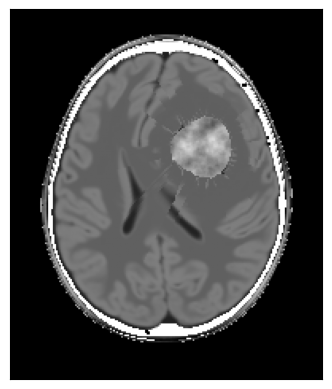

In [18]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], 'brain')

In [19]:
from VITools import Scanner
scanner = Scanner(phantom)

Initializing Scanner object...
----------


*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.8199999928474426-mm pixels (XY), 0.8199999928474426-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing /tmp/tmp1ntm7bdf/9.0 yr NIHPD Head/phantoms/0

In [20]:
scanner.zspan

'dynamic'

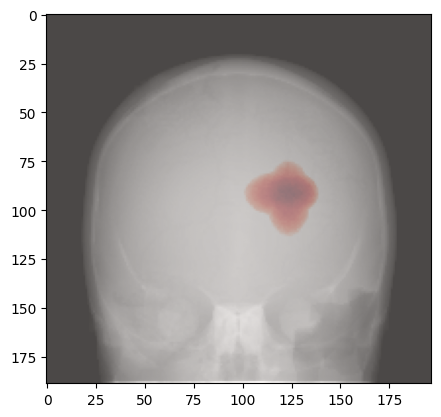

In [21]:
import matplotlib.pyplot as plt
plt.imshow(phantom.get_CT_number_phantom().sum(axis=1), cmap='gray')
plt.imshow(phantom.lesions[0].mask.sum(axis=1), cmap='Reds', alpha=0.3)
# plt.imshow(phantom.lesions[1].mask.sum(axis=1), cmap='Blues', alpha=0.3)

In [22]:
# Add lesion alpha if present to scout view

In [34]:
lesion_volume

{'IPH': [1, 6], 'SDH': [1, 6], 'EDH': [1, 6]}

In [23]:
ICHStudy.generate_from_distributions(get_available_phantoms(),
                                    lesion_volume=lesion_volume,
                                    lesion_attenuation=lesion_attn,
                                    views=100,
                                    scan_coverage=(0, 7),
                                    study_count=1)

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,case_seed,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,add_augmentation
0,case_0000,38.0 yr MIDA Head,Scanner_Default,120.0,300.0,0.0,100.0,"(0, 7)",soft,1,...,417700,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,EDH,1.757576,51.111111,0,38.0,0.882709,True


In [24]:
import pandas as pd
study = ICHStudy()
study.metadata = pd.concat([
    study.metadata,
    ICHStudy.generate_from_distributions(get_available_phantoms(),
                            lesion_volume=lesion_volume,
                            lesion_attenuation=lesion_attn,
                            subtype=['IPH'],
                            views=100,
                            scan_coverage=(0, 7),
                            study_count=1)])
study.metadata

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,edema,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity,age,mass_effect,add_augmentation
0,case_0000,10.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,100.0,"(0, 7)",soft,1,...,0,22.201443,13.419345,3.937105,0.398469,0.334915,0.754008,10.5,0.499711,True


In [25]:
from VITools import available_scanners

In [26]:
study = ICHStudy(ICHStudy.generate_from_distributions(get_available_phantoms(),
                                                      study_count=3,
                                                      lesion_attenuation=lesion_attn,
                                                      lesion_volume=lesion_volume,
                                                      scanner_model=available_scanners,
                                                      views=100,
                                                      scan_coverage=(0, 8),
                                                      seed=88))
study



Input metadata:

     case_id              phantom    scanner_model    kVp     mA  pitch  \
0  case_0000    9.0 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   
1  case_0001   11.5 yr NIHPD Head  Scanner_Default  120.0  300.0    0.0   
2  case_0002  15.75 yr NIHPD Head  Scanner_Default  120.0  300.0    0.0   

   views scan_coverage recon_kernel  slice_thickness  ...  case_seed  \
0  100.0        (0, 8)         soft                1  ...     938928   
1  100.0        (0, 8)         soft                1  ...     688509   
2  100.0        (0, 8)         soft                1  ...     494585   

                                    output_directory  remove_raw  subtype  \
0  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True      SDH   
1  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True     None   
2  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True      SDH   

  lesion_volume  lesion_attenuation edema    age  mass_effect  \
0      4.535354   

In [27]:
study.metadata['mA']

0    300.0
1    300.0
2    300.0
Name: mA, dtype: float64

In [28]:
study.run_all(parallel=False)

qsub not found, running in serial mode


  0%|          | 0/3 [00:00<?, ?it/s]

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.8199999928474426-mm pixels (XY), 0.8199999928474426-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing /ho

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 100/100 [00:24<00:00,  4.00it/s]


...

in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:07<00:00, 12.62it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


/home/brandon.nelson/Dev/PedSilicoICH/.insilicoich/lib/python3.11/site-packages/scipy/ndimage/_measurements.py:1548: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer
Scans completed in parallel:   0%|          | 0/3 [00:00<?, ?it/s]



Input metadata:

     case_id              phantom    scanner_model    kVp     mA  pitch  \
0  case_0000    9.0 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   
1  case_0001   11.5 yr NIHPD Head  Scanner_Default  120.0  300.0    0.0   
2  case_0002  15.75 yr NIHPD Head  Scanner_Default  120.0  300.0    0.0   

   views scan_coverage recon_kernel  slice_thickness  ...  case_seed  \
0  100.0        (0, 8)         soft                1  ...     938928   
1  100.0        (0, 8)         soft                1  ...     688509   
2  100.0        (0, 8)         soft                1  ...     494585   

                                    output_directory  remove_raw  subtype  \
0  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True      SDH   
1  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True     None   
2  /home/brandon.nelson/Dev/PedSilicoICH/notebook...        True      SDH   

  lesion_volume  lesion_attenuation edema    age  mass_effect  \
0      4.535354   

I would like to merge the metadata with the results, updating column/row info as updated following the scan and adding new info such as image/mask location

In [29]:
study.metadata

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,case_seed,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,add_augmentation
0,case_0000,9.0 yr NIHPD Head,GE_Lightspeed16,120.0,300.0,0.0,100.0,"(0, 8)",soft,1,...,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,4.535354,74.343434,0,9.00,0.651095,True
1,case_0001,11.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,100.0,"(0, 8)",soft,1,...,688509,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,None,0.000000,0.000000,0,11.50,0.629951,True
2,case_0002,15.75 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,100.0,"(0, 8)",soft,1,...,494585,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,True,SDH,1.858586,55.656566,0,15.75,0.264914,True


In [30]:
study.results

,case_id,name,age,kVp,mA,pitch,views,scanner_model,recon_kernel,slice_thickness,slice_increment,fov,case_seed,image_file_path,subtype,lesion_volume(mL),lesion_attenuation(HU),mass_effect,"lesion_location(z,y,x)",mask_file_path
0,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
1,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
2,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
3,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
4,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
5,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
6,case_0000,9.0 yr NIHPD Head,9.00,120.0,300.0,0.0,100.0,GE_Lightspeed16,soft,1,1,250,938928,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/home/brandon.nelson/Dev/PedSilicoICH/notebook...
7,case_0001,11.5 yr NIHPD Head,11.50,120.0,300.0,0.0,100.0,Scanner_Default,soft,1,1,250,688509,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,NaN,0.0,0.0,0.629951,NaN,NaN
8,case_0001,11.5 yr NIHPD Head,11.50,120.0,300.0,0.0,100.0,Scanner_Default,soft,1,1,250,688509,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,NaN,0.0,0.0,0.629951,NaN,NaN
9,case_0001,11.5 yr NIHPD Head,11.50,120.0,300.0,0.0,100.0,Scanner_Default,soft,1,1,250,688509,/home/brandon.nelson/Dev/PedSilicoICH/notebook...,NaN,0.0,0.0,0.629951,NaN,NaN


In [31]:
# mask = study.get_masks(0)
imgs = study.get_images(0)

In [32]:
imgs

array([[[-1088, -1092, -1094, ..., -1093, -1094, -1095],
        [-1083, -1090, -1093, ..., -1093, -1093, -1096],
        [-1084, -1090, -1096, ..., -1092, -1091, -1097],
        ...,
        [-1068, -1065, -1059, ..., -1108, -1115, -1114],
        [-1057, -1055, -1048, ..., -1094, -1105, -1111],
        [-1051, -1050, -1046, ..., -1087, -1092, -1099]],

       [[ -963,  -996, -1038, ...,  -930,  -960, -1016],
        [ -939,  -971, -1005, ...,  -924,  -994, -1054],
        [ -932,  -949,  -993, ...,  -978, -1053, -1077],
        ...,
        [-1006, -1014, -1014, ..., -1147, -1178, -1175],
        [ -999,  -994,  -982, ..., -1098, -1170, -1166],
        [ -968,  -972,  -976, ..., -1056, -1133, -1173]],

       [[ -973,  -991, -1041, ...,  -920,  -957,  -999],
        [ -947,  -979, -1000, ...,  -904,  -964, -1017],
        [ -925,  -945,  -982, ...,  -936, -1017, -1053],
        ...,
        [ -998,  -999, -1016, ..., -1160, -1161, -1138],
        [ -980,  -994, -1009, ..., -1135, -11

NameError: name 'mask' is not defined

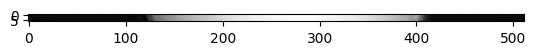

In [33]:
import matplotlib.pyplot as plt
plt.imshow(imgs.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.2)

In [ ]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
images = study.get_images(2)
masks = study.get_masks(2)
images.shape, masks.shape

((54, 512, 512), (54, 512, 512))

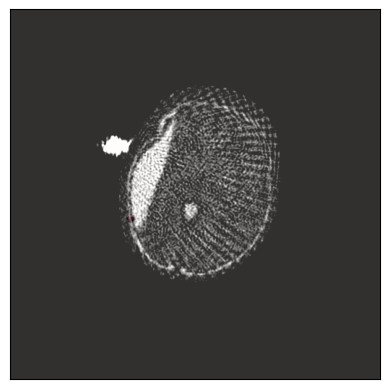

In [ ]:
from utils import ctshow
import matplotlib.pyplot as plt
f, ax = plt.subplots()
idx = len(images) // 2
ctshow(images[idx], 'brain', fig=f, ax=ax)
ax.imshow(masks[idx], cmap='Reds', alpha=0.2)

In [ ]:
from utils import scrollview
scrollview(images, 'brain')

interactive(children=(IntSlider(value=27, description='idx', max=53), Output()), _dom_classes=('widget-interac…